# 06 — Effective inventory Ĩ and damped survival-weighted base-stock (CTL-01)

This notebook explores how the controller counts **what you really have on the shelf** before placing an order.

- **`effective_inventory`** (`filter/belief.py`) — survival-weighted on-hand plus a pipeline term, vs a naive sum of lot counts.
- **`survival_weighted_on_hand`** (`filter/age_likelihood/survival.py`) — the on-hand piece: $\sum_\ell n_\ell\,\mathbb E[S(\tau_\ell)]$ under age marginals.
- **`DampedSurvivalWeightedPolicy`** (`sim/bakeoff_damped_sw.py`) — CTL-01=C: $q_t = \mathrm{caseRound}(\rho\,[F^{-1}(\alpha) - \tilde I_t]^+)$.

We also contrast the **ADR board formula** for lot weights $w(\tau)=S(\tau+\Delta\tau_L)/S(\tau)$ with the **implemented** weight $S(\tau)$, and show the $\beta=1$ flat-weight degeneracy that makes age-aware and age-blind policies coincide.

## Setup

From the repo root:

```bash
uv sync --extra notebooks
uv run jupyter lab notebooks/
```

Then open this notebook and run all cells. Imports use the editable `blueberries_voi` install; fixtures mirror `tests/test_belief.py` and `tests/test_m2_gates.py` (β=1 degeneracy gate).

In [1]:
%matplotlib inline

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import nbinom

import blueberries_voi
from blueberries_voi.filter.age_likelihood import survival_weighted_on_hand
from blueberries_voi.filter.belief import (
    ShelfBelief,
    effective_inventory,
    shelf_belief_from_oracle,
)
from blueberries_voi.model import ModelParams, q10_age_increment, weibull_survival
from blueberries_voi.sim.bakeoff_damped_sw import (
    DampedSurvivalWeightedPolicy,
    protection_demand_quantile,
)
from blueberries_voi.sim.bakeoff_ordering import case_round

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").exists():
    REPO = REPO.parent  # launched from notebooks/

print(f"blueberries_voi {getattr(blueberries_voi, '__version__', 'dev')}")

%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

params = ModelParams()  # defaults: β=2, η=14 d, μ=30, case_size=8
DELTA_TAU_L = q10_age_increment(
    1.0,
    t_store_c=params.t_store_c,
    t_ref_c=params.t_ref_c,
    q10=params.q10,
)
print(f"ModelParams defaults: β={params.beta}, η={params.eta_ref} d, μ={params.demand_mu}")
print(f"Lead-time age increment Δτ_L = {DELTA_TAU_L:.3f} effective-age days")

blueberries_voi 0.1.0
ModelParams defaults: β=2.0, η=14.0 d, μ=30.0
Lead-time age increment Δτ_L = 1.552 effective-age days


## 1. Naive on-hand vs effective inventory Ĩ

A **naive** count adds every unit on the shelf: $\sum_\ell n_\ell$.

**Effective inventory** discounts each lot by how likely its berries are still alive when demand arrives. The on-hand term is

$$
\sum_\ell n_\ell \,\mathbb E_{q(\tau_\ell)}[S(\tau_\ell)]
$$

computed by `survival_weighted_on_hand(..., from_marginals=True)`. Pending pipeline units get a flat-prior expected survival weight (ADR 0092).

```python
# belief.py — effective_inventory
on_hand = survival_weighted_on_hand(n, marginals, ..., from_marginals=True)
pipeline = sum(qty * E_grid[S(τ)] for qty in pending_orders.values())
return on_hand + pipeline
```

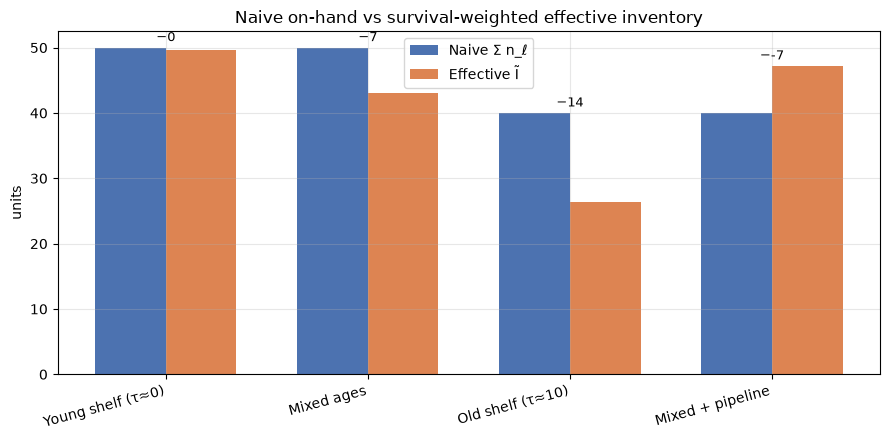

Young shelf (τ≈0)       naive= 50.0  Ĩ= 49.6  gap=  0.4
Mixed ages              naive= 50.0  Ĩ= 43.0  gap=  7.0
Old shelf (τ≈10)        naive= 40.0  Ĩ= 26.4  gap= 13.6
Mixed + pipeline        naive= 40.0  Ĩ= 47.2  gap= -7.2


In [2]:
def make_belief(lot_counts: list[int], ages: list[float], tau_grid: list[float]) -> ShelfBelief:
    return shelf_belief_from_oracle(lot_counts=lot_counts, ages=ages, tau_grid=tau_grid)


def naive_on_hand(belief: ShelfBelief) -> float:
    return float(sum(belief.lot_counts))


def compare_naive_vs_effective(
    label: str,
    lot_counts: list[int],
    ages: list[float],
    *,
    pending: dict[int, int] | None = None,
    tau_grid: list[float] | None = None,
) -> dict[str, float]:
    grid = tau_grid or [float(x) for x in range(0, 15, 2)]
    belief = make_belief(lot_counts, ages, grid)
    pending = pending or {}
    naive = naive_on_hand(belief)
    i_tilde = effective_inventory(belief, pending_orders=pending, params=params)
    return {"label": label, "naive": naive, "effective": i_tilde, "gap": naive - i_tilde}


GRID = [float(x) for x in range(0, 15, 2)]
scenarios = [
    compare_naive_vs_effective("Young shelf (τ≈0)", [30, 20], [0.0, 2.0]),
    compare_naive_vs_effective("Mixed ages", [25, 25], [0.0, 8.0]),
    compare_naive_vs_effective("Old shelf (τ≈10)", [20, 20], [8.0, 10.0]),
    compare_naive_vs_effective("Mixed + pipeline", [30, 10], [2.0, 10.0], pending={1: 16}),
]

labels = [s["label"] for s in scenarios]
naive_vals = [s["naive"] for s in scenarios]
eff_vals = [s["effective"] for s in scenarios]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width / 2, naive_vals, width, label="Naive Σ n_ℓ", color="#4C72B0")
ax.bar(x + width / 2, eff_vals, width, label="Effective Ĩ", color="#DD8452")
ax.set_xticks(x, labels, rotation=15, ha="right")
ax.set_ylabel("units")
ax.set_title("Naive on-hand vs survival-weighted effective inventory")
ax.legend()
for i, (n, e) in enumerate(zip(naive_vals, eff_vals)):
    ax.annotate(f"−{n - e:.0f}", (x[i], max(n, e) + 1), ha="center", fontsize=9)
fig.tight_layout()
plt.show()

for s in scenarios:
    print(f"{s['label']:22s}  naive={s['naive']:5.1f}  Ĩ={s['effective']:5.1f}  gap={s['gap']:5.1f}")

## 2. ADR weight formula vs implemented weight

ADR 0058 (CTL-01) states lot weights as a **forward survival ratio** through lead time:

$$
w_{\mathrm{ADR}}(\tau) = \frac{S(\tau + \Delta\tau_L)}{S(\tau)}
$$

where $\Delta\tau_L$ is the effective-age advance over one calendar day of lead time (`q10_age_increment(1.0, ...)`).

The **implemented** on-hand weight in `survival_weighted_on_hand` uses the **level** survival $S(\tau)$ directly (same in Python and the Rust `voi_core` policy kernel). The plots below show both curves and the resulting Ĩ on a single-lot shelf.

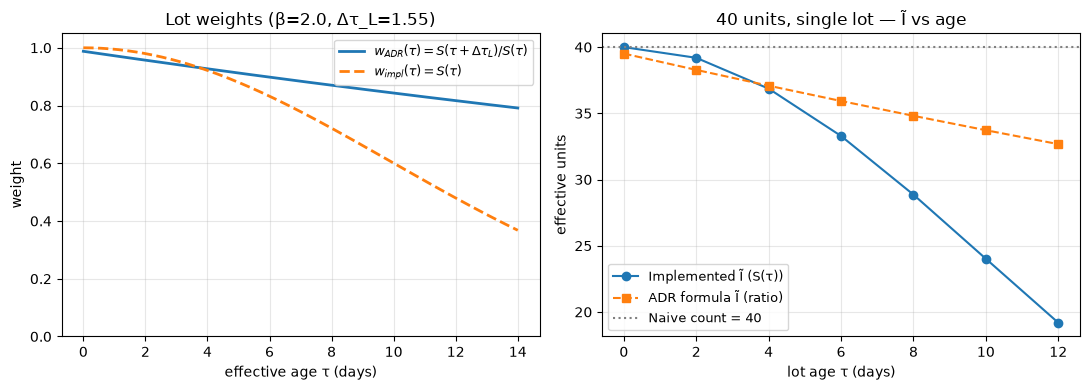

In [3]:
def adr_weight(tau: float, *, delta_tau_l: float, beta: float, eta: float) -> float:
    s_tau = weibull_survival(tau, beta=beta, eta=eta)
    if s_tau <= 0.0:
        return 0.0
    s_fwd = weibull_survival(tau + delta_tau_l, beta=beta, eta=eta)
    return s_fwd / s_tau


def implemented_weight(tau: float, *, beta: float, eta: float) -> float:
    return weibull_survival(tau, beta=beta, eta=eta)


def effective_inventory_adr(
    belief: ShelfBelief,
    *,
    pending_orders: dict[int, int],
    params: ModelParams,
    delta_tau_l: float,
) -> float:
    """Hand-computed Ĩ using ADR ratio weights w(τ)=S(τ+Δτ)/S(τ)."""
    on_hand = 0.0
    marg = np.asarray(belief.age_marginals, dtype=float)
    for ell, n_l in enumerate(belief.lot_counts):
        e_w = 0.0
        for k, tau in enumerate(belief.tau_grid):
            w = adr_weight(
                tau,
                delta_tau_l=delta_tau_l,
                beta=params.beta,
                eta=params.eta_ref,
            )
            e_w += float(marg[ell, k]) * w
        on_hand += float(n_l) * e_w
    # Pipeline: flat-prior mean of ADR weights on the grid (mirrors belief.py pipeline spirit)
    pipe_w = float(
        np.mean(
            [
                adr_weight(
                    tau,
                    delta_tau_l=delta_tau_l,
                    beta=params.beta,
                    eta=params.eta_ref,
                )
                for tau in belief.tau_grid
            ]
        )
    )
    pipeline = sum(float(q) * pipe_w for q in pending_orders.values())
    return float(on_hand + pipeline)


tau_plot = np.linspace(0.0, 14.0, 200)
w_adr = [adr_weight(t, delta_tau_l=DELTA_TAU_L, beta=params.beta, eta=params.eta_ref) for t in tau_plot]
w_impl = [implemented_weight(t, beta=params.beta, eta=params.eta_ref) for t in tau_plot]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tau_plot, w_adr, label=r"$w_{ADR}(\tau)=S(\tau+\Delta\tau_L)/S(\tau)$", lw=2)
axes[0].plot(tau_plot, w_impl, label=r"$w_{impl}(\tau)=S(\tau)$", lw=2, ls="--")
axes[0].set_xlabel("effective age τ (days)")
axes[0].set_ylabel("weight")
axes[0].set_title(f"Lot weights (β={params.beta}, Δτ_L={DELTA_TAU_L:.2f})")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)

# Single-lot Ĩ vs age (no pipeline)
ages_demo = np.arange(0, 14, 2)
i_impl = []
i_adr = []
for age in ages_demo:
    b = make_belief([40], [float(age)], GRID)
    i_impl.append(effective_inventory(b, pending_orders={}, params=params))
    i_adr.append(effective_inventory_adr(b, pending_orders={}, params=params, delta_tau_l=DELTA_TAU_L))

axes[1].plot(ages_demo, i_impl, "o-", label="Implemented Ĩ (S(τ))")
axes[1].plot(ages_demo, i_adr, "s--", label="ADR formula Ĩ (ratio)")
axes[1].axhline(40, color="gray", ls=":", label="Naive count = 40")
axes[1].set_xlabel("lot age τ (days)")
axes[1].set_ylabel("effective units")
axes[1].set_title("40 units, single lot — Ĩ vs age")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

## 3. Young vs old shelf mixes

With the same **total** on-hand count, shifting mass from young to old lots lowers Ĩ because $S(\tau)$ falls with age. The gap is largest when one cohort is near the end of its shelf life.

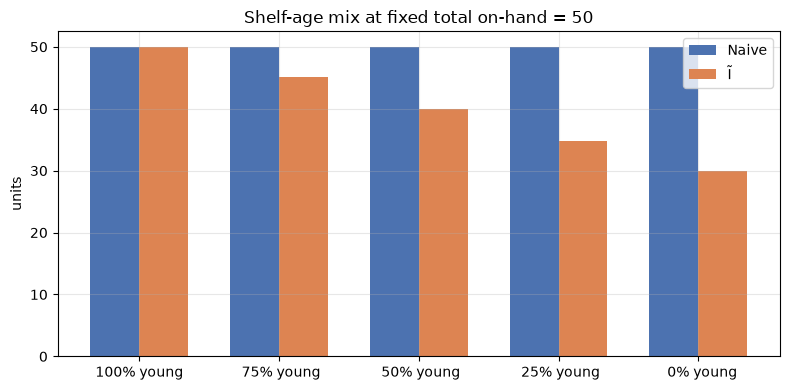

100% young: naive=50  Ĩ=50.0  discount=0.0
 75% young: naive=50  Ĩ=45.2  discount=4.8
 50% young: naive=50  Ĩ=40.0  discount=10.0
 25% young: naive=50  Ĩ=34.8  discount=15.2
  0% young: naive=50  Ĩ=30.0  discount=20.0


In [4]:
TOTAL = 50
mix_labels: list[str] = []
mix_naive: list[float] = []
mix_eff: list[float] = []

for young_share in (1.0, 0.75, 0.5, 0.25, 0.0):
    n_young = int(round(TOTAL * young_share))
    n_old = TOTAL - n_young
    counts = [n_young, n_old] if n_old > 0 else [n_young]
    ages = [0.0, 10.0][: len(counts)]
    belief = make_belief(counts, ages, GRID)
    mix_labels.append(f"{int(young_share * 100):>3}% young")
    mix_naive.append(naive_on_hand(belief))
    mix_eff.append(effective_inventory(belief, pending_orders={}, params=params))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(mix_labels))
ax.bar(x - width / 2, mix_naive, width, label="Naive", color="#4C72B0")
ax.bar(x + width / 2, mix_eff, width, label="Ĩ", color="#DD8452")
ax.set_xticks(x, mix_labels)
ax.set_ylabel("units")
ax.set_title(f"Shelf-age mix at fixed total on-hand = {TOTAL}")
ax.legend()
fig.tight_layout()
plt.show()

for lbl, n, e in zip(mix_labels, mix_naive, mix_eff):
    print(f"{lbl}: naive={n:.0f}  Ĩ={e:.1f}  discount={n - e:.1f}")

## 4. β = 1 flat-weight degeneracy

Under **proportional decay** (Weibull with $\beta=1$), the ADR ratio weight is **constant in τ**:

$$
w_{\mathrm{ADR}}(\tau) = \frac{S(\tau+\Delta\tau_L)}{S(\tau)} = S(\Delta\tau_L) \quad\text{(independent of }\tau\text{)}.
$$

Every lot is discounted by the same factor, so age-aware effective inventory collapses to a scalar multiple of the naive count — the M2 **β=1 degeneracy gate** (`sim/m2_gates.py`) checks that `DampedSurvivalWeightedPolicy` then agrees with the age-blind Rung-0 policy.

Note: the **implemented** $S(\tau)$ weights are *not* flat at $\beta=1$; only the ADR ratio form has this degeneracy. The gate uses matched scalar weights derived from `effective_inventory` on unit fixtures.

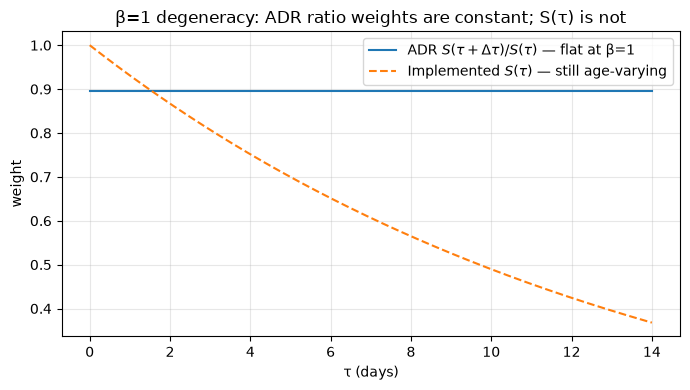

ADR flat weight at β=1: 0.8951  (= S(Δτ_L) = 0.8951)
β=1 gate fixture: age-blind q=24, age-aware q=24  (match=True)


In [5]:
beta1 = ModelParams(beta=1.0)
dtau_b1 = q10_age_increment(1.0, t_store_c=beta1.t_store_c, t_ref_c=beta1.t_ref_c, q10=beta1.q10)
tau_plot = np.linspace(0.0, 14.0, 200)

w_adr_b1 = [adr_weight(t, delta_tau_l=dtau_b1, beta=1.0, eta=beta1.eta_ref) for t in tau_plot]
w_impl_b1 = [implemented_weight(t, beta=1.0, eta=beta1.eta_ref) for t in tau_plot]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tau_plot, w_adr_b1, label=r"ADR $S(\tau+\Delta\tau)/S(\tau)$ — flat at β=1")
ax.plot(tau_plot, w_impl_b1, ls="--", label=r"Implemented $S(\tau)$ — still age-varying")
ax.set_xlabel("τ (days)")
ax.set_ylabel("weight")
ax.set_title("β=1 degeneracy: ADR ratio weights are constant; S(τ) is not")
ax.legend()
fig.tight_layout()
plt.show()

flat_level = w_adr_b1[0]
print(f"ADR flat weight at β=1: {flat_level:.4f}  (= S(Δτ_L) = {weibull_survival(dtau_b1, beta=1.0, eta=beta1.eta_ref):.4f})")

# Demonstrate order equality on the gate fixture (ρ=1, same ages → flat implemented marginals)
from blueberries_voi.controller.rung0 import CorrectedAgeBlindPolicy

grid_gate = [0.0, 1.0, 2.0, 3.0, 4.0]
lots = [20.0, 20.0]
pending = {1: 16}
margs = [[1.0, 0.0, 0.0, 0.0, 0.0] for _ in lots]  # both lots at τ=0
belief_gate = ShelfBelief(lot_counts=lots, age_marginals=margs, tau_grid=grid_gate)
alpha, rho = 0.9, 1.0

bar_w = effective_inventory(
    ShelfBelief(lot_counts=[1.0], age_marginals=[margs[0]], tau_grid=grid_gate),
    pending_orders={},
    params=beta1,
)
pipe_w = effective_inventory(
    ShelfBelief(lot_counts=[0.0], age_marginals=[margs[0]], tau_grid=grid_gate),
    pending_orders={1: 1},
    params=beta1,
)
d_star = float(nbinom.ppf(alpha, beta1.nb_r() * 2.0, beta1.nb_p()))

q_blind = CorrectedAgeBlindPolicy(
    alpha=alpha,
    params=beta1,
    rho=rho,
    mean_survival_weight=bar_w,
    pipeline_weight=pipe_w,
    demand_target=d_star,
    protection_days=2,
    case_size=8,
).order(0, belief_gate, pending_orders=pending)
q_aware = DampedSurvivalWeightedPolicy(rho=rho, alpha=alpha, params=beta1).order(
    belief_gate, pending_orders=pending
)
print(f"β=1 gate fixture: age-blind q={q_blind}, age-aware q={q_aware}  (match={q_blind == q_aware})")

## 5. Damped survival-weighted base-stock (CTL-01=C)

`DampedSurvivalWeightedPolicy` implements ADR 0058:

$$
q_t = \mathrm{caseRound}\big(\rho\,[F^{-1}_{D_{t:t+L}}(\alpha) - \tilde I_t]^+\big)
$$

- $\tilde I_t$ from `effective_inventory` on `ShelfBelief` (MF marginals).
- $F^{-1}$ is the protection-interval demand quantile (`protection_demand_quantile`; legacy no-schedule path uses 2 days).
- Default **ρ = 0.8** (Nahmias damping) corrects the base-stock family's structural over-response to inventory.
- Orders snap to **case multiples** via `case_round`.

The Rust `voi_core` kernel mirrors the same formula for production sim runs; this section exercises the Python reference implementation.

In [6]:
belief_demo = make_belief([20, 10], [0.0, 4.0], GRID)
pending_demo = {1: 8}
i_tilde = effective_inventory(belief_demo, pending_orders=pending_demo, params=params)
alpha_demo = 0.9
d_star = protection_demand_quantile(alpha_demo, params, protection_days=2)

policy = DampedSurvivalWeightedPolicy(rho=0.8, alpha=alpha_demo, params=params)
q = policy.order(belief_demo, pending_orders=pending_demo)

raw = 0.8 * max(0.0, d_star - i_tilde)
print(f"Ĩ_t = {i_tilde:.2f}")
print(f"F⁻¹(α={alpha_demo}) over 2 days = {d_star:.2f}")
print(f"ρ·[D* − Ĩ]⁺ = {raw:.2f}  →  case_round = {case_round(raw, params.case_size)}  (policy.order = {q})")

Ĩ_t = 35.12
F⁻¹(α=0.9) over 2 days = 74.00
ρ·[D* − Ĩ]⁺ = 31.10  →  case_round = 32  (policy.order = 32)


## 6. Order quantity sensitivity

How does the recommended order respond to shelf age (via Ĩ) and to policy knobs ρ and α?

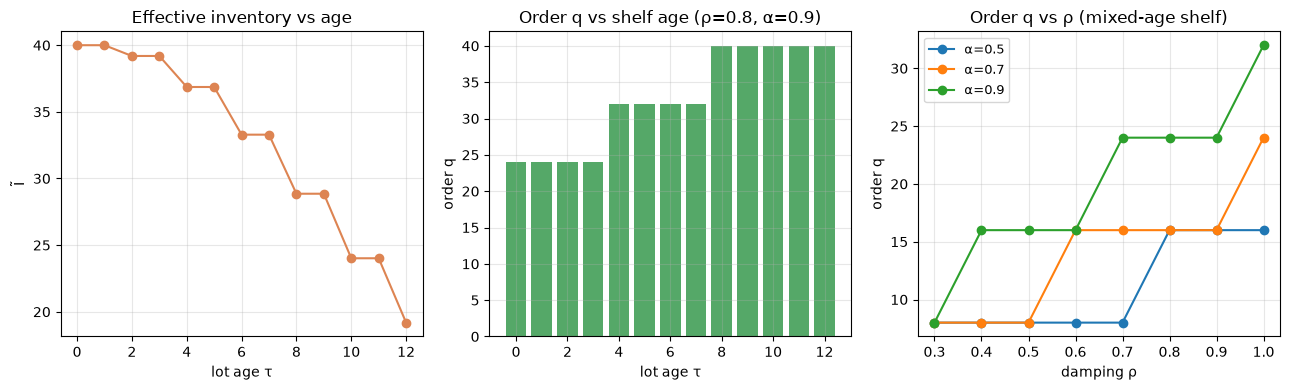

In [7]:
# Sensitivity to shelf age (single lot, fixed count)
ages_sweep = np.arange(0, 13, 1)
qs_by_age: list[int] = []
i_by_age: list[float] = []
pol = DampedSurvivalWeightedPolicy(rho=0.8, alpha=0.9, params=params)

for age in ages_sweep:
    b = make_belief([40], [float(age)], GRID)
    i_by_age.append(effective_inventory(b, pending_orders={}, params=params))
    qs_by_age.append(pol.order(b))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(ages_sweep, i_by_age, "o-", color="#DD8452")
axes[0].set_xlabel("lot age τ")
axes[0].set_ylabel("Ĩ")
axes[0].set_title("Effective inventory vs age")

axes[1].bar(ages_sweep, qs_by_age, color="#55A868")
axes[1].set_xlabel("lot age τ")
axes[1].set_ylabel("order q")
axes[1].set_title("Order q vs shelf age (ρ=0.8, α=0.9)")

# Sensitivity to ρ and α on a mixed-age fixture
belief_mix = make_belief([25, 25], [0.0, 8.0], GRID)
rhos = np.linspace(0.3, 1.0, 8)
alphas = [0.5, 0.7, 0.9]
for a in alphas:
    qs = [
        DampedSurvivalWeightedPolicy(rho=float(r), alpha=a, params=params).order(belief_mix)
        for r in rhos
    ]
    axes[2].plot(rhos, qs, "o-", label=f"α={a}")
axes[2].set_xlabel("damping ρ")
axes[2].set_ylabel("order q")
axes[2].set_title("Order q vs ρ (mixed-age shelf)")
axes[2].legend(fontsize=9)

fig.tight_layout()
plt.show()

## Takeaways

1. **Ĩ < naive** whenever lots have positive effective age; the gap widens for older shelf mixes.
2. **ADR ratio weights** $S(\tau+\Delta\tau_L)/S(\tau)$ differ from the **implemented** $S(\tau)$ weights; at $\beta=1$ the ADR form is flat in τ (Van Zyl degeneracy), while $S(\tau)$ still varies.
3. **CTL-01=C** turns Ĩ into an order via a damped base-stock rule; ρ and α provide levers on how aggressively the store replenishes.
4. Production sims may execute the same math in Rust (`voi_core`); this notebook uses the Python reference path for exploration and figures.